# Grammar Nondeterminism Analysis

This notebook analyzes the grammar to determine:
1. How many sentences have multiple valid classes for the last word
2. Which grammar rules allow multiple valid classes at different positions
3. Statistics on ambiguity in the generated corpus


In [9]:
import numpy as np
import json
import os
from collections import Counter, defaultdict
from nltk import CFG, ChartParser
from nltk.corpus import brown
from nltk.probability import FreqDist
from random import choice
import matplotlib.pyplot as plt

# Set random seed
np.random.seed(42)

print("Loading grammar and corpora...")


Loading grammar and corpora...


In [10]:
# Load saved corpora
corpora_dir = "corpora"

with open(os.path.join(corpora_dir, 'uniform_corpus.json'), 'r', encoding='utf-8') as f:
    uniform_corpus = json.load(f)

with open(os.path.join(corpora_dir, 'zipfian_corpus.json'), 'r', encoding='utf-8') as f:
    zipfian_corpus = json.load(f)

uniform_sentences = uniform_corpus['sentences']
uniform_classes = uniform_corpus['classes']
zipfian_sentences = zipfian_corpus['sentences']
zipfian_classes = zipfian_corpus['classes']

print(f"Loaded {len(uniform_sentences):,} uniform sentences")
print(f"Loaded {len(zipfian_sentences):,} zipfian sentences")


Loaded 100,000 uniform sentences
Loaded 100,000 zipfian sentences


In [11]:
# Recreate grammar (same as original notebook)
def clean_word(word):
    """Remove disambiguation suffixes like _1, _2"""
    if '_' in word:
        return word.rsplit('_', 1)[0]
    return word

# Build word lists from Brown corpus
tagged = brown.tagged_words(tagset='universal')
nouns = [w.lower() for w, t in tagged if t == 'NOUN']
verbs = [w.lower() for w, t in tagged if t == 'VERB']
dets  = [w.lower() for w, t in tagged if t == 'DET']
adjs  = [w.lower() for w, t in tagged if t == 'ADJ']
preps = [w.lower() for w, t in tagged if t == 'ADP']

def top_clean(words, n):
    fd = FreqDist(words)
    result = []
    for w, _ in fd.most_common():
        if not w.isalpha() or "'" in w or "\\" in w:
            continue
        result.append(w)
        if len(result) >= n:
            break
    return result

top_nouns = top_clean(nouns, 100)
top_verbs = top_clean(verbs, 100)
top_dets = top_clean(dets, 20)
top_adjs = top_clean(adjs, 50)
top_preps = top_clean(preps, 30)

# Create disambiguated word lists
disambig_nouns = [f"{w}(N)" for w in top_nouns]
disambig_verbs = [f"{w}(V)" for w in top_verbs]
disambig_dets = [f"{w}(Det)" for w in top_dets]
disambig_adjs = [f"{w}(Adj)" for w in top_adjs]
disambig_preps = [f"{w}(P)" for w in top_preps]

# Create grammar rules
noun_rules = [f"N -> '{w}'" for w in disambig_nouns]
verb_rules = [f"V -> '{w}'" for w in disambig_verbs]
det_rules = [f"Det -> '{w}'" for w in disambig_dets]
adj_rules = [f"Adj -> '{w}'" for w in disambig_adjs]
prep_rules = [f"P -> '{w}'" for w in disambig_preps]

# Word to category mapping
word2cats = {}
def add_mapping(words, cat):
    for w in words:
        word2cats.setdefault(clean_word(w), set()).add(cat)

add_mapping(disambig_nouns, 'N')
add_mapping(disambig_verbs, 'V')
add_mapping(disambig_dets,  'Det')
add_mapping(disambig_adjs,  'Adj')
add_mapping(disambig_preps, 'P')

# Base grammar
base_grammar = """
S -> NP VP
PP -> P NP
NP -> Det N | Det Adj N | Det N PP | Det Adj N PP | 'I'
VP -> V NP | VP PP
"""

full_grammar_str = (
    base_grammar
    + "\n"
    + "\n".join(noun_rules + verb_rules + det_rules + adj_rules + prep_rules)
)

grammar = CFG.fromstring(full_grammar_str)
parser = ChartParser(grammar)
gr = parser.grammar()

print("✓ Grammar loaded")


✓ Grammar loaded


In [12]:
# Method 1: Analyze grammar rules to find positions with multiple valid classes
print("="*60)
print("METHOD 1: ANALYZING GRAMMAR RULES")
print("="*60)

# For each production rule, check what can follow
# Focus on rules that can end sentences or lead to the last word

# Rules that can produce the last word in a sentence:
# - VP -> V NP (last word could be N from NP)
# - VP -> VP PP (last word could be N from PP -> P NP -> ... -> N)
# - NP -> Det N (last word is N)
# - NP -> Det Adj N (last word is N)
# - NP -> Det N PP (last word could be N from PP)
# - NP -> Det Adj N PP (last word could be N from PP)

# Check what can be the last word class
possible_last_classes = set()

# Direct: NP ending in N
possible_last_classes.add('N')

# From PP: PP -> P NP, and NP can end in N, so PP can end in N
# But PP itself is P, so if sentence ends with PP, last word is P
possible_last_classes.add('P')

# From VP -> V NP: if NP ends in N, last word is N
# From VP -> VP PP: if PP ends in N (from NP), last word is N
# But VP itself starts with V, so if sentence is just VP, first word is V

# Actually, let's think about sentence structure: S -> NP VP
# The last word comes from VP, which can be:
# - VP -> V NP: last word from NP (which can be N)
# - VP -> VP PP: last word from PP (which is P, or N if PP -> P NP -> ... -> N)

# So last word can be: N (from NP in VP), P (from PP), or potentially V if VP is just V?

# Let's check all productions that can lead to terminal symbols
terminal_productions = {}
for production in grammar.productions():
    lhs = str(production.lhs())
    if len(production.rhs()) == 1 and isinstance(production.rhs()[0], str):
        # Terminal production
        if lhs not in terminal_productions:
            terminal_productions[lhs] = []
        terminal_productions[lhs].append(production.rhs()[0])

print(f"\nTerminal productions by category:")
for cat, terms in terminal_productions.items():
    print(f"  {cat}: {len(terms)} words")

# Now check what categories can appear at the end of different structures
print(f"\nPossible last word classes from grammar analysis:")
print(f"  N: Yes (from NP)")
print(f"  P: Yes (from PP)")
print(f"  V: Possibly (if VP -> V with no NP)")
print(f"  Det: Unlikely (usually starts NP)")
print(f"  Adj: Unlikely (usually before N)")

# More systematic: generate many sentences and check what classes appear at the end
print(f"\n{'='*60}")
print("METHOD 2: EMPIRICAL ANALYSIS FROM GENERATED SENTENCES")
print(f"{'='*60}")


METHOD 1: ANALYZING GRAMMAR RULES

Terminal productions by category:
  NP: 1 words
  N: 100 words
  V: 100 words
  Det: 20 words
  Adj: 50 words
  P: 30 words

Possible last word classes from grammar analysis:
  N: Yes (from NP)
  P: Yes (from PP)
  V: Possibly (if VP -> V with no NP)
  Det: Unlikely (usually starts NP)
  Adj: Unlikely (usually before N)

METHOD 2: EMPIRICAL ANALYSIS FROM GENERATED SENTENCES


In [13]:
# Analyze which contexts (first n-1 word CLASSES) allow multiple classes for the nth word
# We use class sequences, not words, since grammar nondeterminism is about class patterns

n_context = 5  # Same as training: use first 4 word classes to predict 5th

context_to_classes = defaultdict(set)  # Map class context -> set of possible next classes
context_counts = Counter()  # Count how many times each class context appears

print(f"Analyzing class contexts of length {n_context-1}...")
print(f"Checking if same class context can have different next word classes...")

for sentences, classes_list in [(uniform_sentences, uniform_classes), (zipfian_sentences, zipfian_classes)]:
    for sent, classes in zip(sentences, classes_list):
        if len(classes) >= n_context:
            # Get context as sequence of classes (first n-1 classes)
            context_classes = classes[:n_context-1]
            context_str = ' '.join(context_classes)  # Use class sequence, not words
            last_class = classes[n_context-1]
            
            context_to_classes[context_str].add(last_class)
            context_counts[context_str] += 1

print(f"\nTotal unique contexts: {len(context_to_classes):,}")
print(f"Total context occurrences: {sum(context_counts.values()):,}")

# Count how many contexts allow multiple classes
ambiguous_contexts = {ctx: classes for ctx, classes in context_to_classes.items() if len(classes) > 1}
unambiguous_contexts = {ctx: classes for ctx, classes in context_to_classes.items() if len(classes) == 1}

print(f"\nContexts with multiple possible classes: {len(ambiguous_contexts):,} ({100*len(ambiguous_contexts)/len(context_to_classes):.2f}%)")
print(f"Contexts with single possible class: {len(unambiguous_contexts):,} ({100*len(unambiguous_contexts)/len(context_to_classes):.2f}%)")

# Count sentences that have ambiguous contexts
ambiguous_sentence_count = 0
ambiguous_sentence_examples = []

for sentences, classes_list in [(uniform_sentences, uniform_classes), (zipfian_sentences, zipfian_classes)]:
    for sent, classes in zip(sentences, classes_list):
        if len(classes) >= n_context:
            context_classes = classes[:n_context-1]
            context_str = ' '.join(context_classes)
            if context_str in ambiguous_contexts:
                ambiguous_sentence_count += 1
                if len(ambiguous_sentence_examples) < 10:
                    # Store example with class sequence
                    ambiguous_sentence_examples.append((sent, context_str, context_to_classes[context_str], classes[:n_context]))

total_sentences = len(uniform_sentences) + len(zipfian_sentences)
print(f"\nSentences with ambiguous class contexts: {ambiguous_sentence_count:,} ({100*ambiguous_sentence_count/total_sentences:.2f}%)")

print(f"\nExample ambiguous class contexts (showing first 10):")
for i, (sent, ctx, possible_classes, full_context) in enumerate(ambiguous_sentence_examples[:10], 1):
    print(f"\n  {i}. Class context: '{ctx}'")
    print(f"     Possible next classes: {sorted(possible_classes)}")
    print(f"     Full sequence (first {n_context} classes): {' '.join(full_context)}")
    print(f"     Example sentence: {sent[:80]}...")


Analyzing class contexts of length 4...
Checking if same class context can have different next word classes...

Total unique contexts: 9
Total context occurrences: 200,000

Contexts with multiple possible classes: 5 (55.56%)
Contexts with single possible class: 4 (44.44%)

Sentences with ambiguous class contexts: 157,361 (78.68%)

Example ambiguous class contexts (showing first 10):

  1. Class context: 'Det Adj N P'
     Possible next classes: ['Det', 'OTHER']
     Full sequence (first 5 classes): Det Adj N P Det
     Example sentence: its less plan among their sure values seem I since I...

  2. Class context: 'Det Adj N P'
     Possible next classes: ['Det', 'OTHER']
     Full sequence (first 5 classes): Det Adj N P OTHER
     Example sentence: that(Det) general plan for I may an able values beyond those fine land among thy...

  3. Class context: 'Det Adj N V'
     Possible next classes: ['Det', 'OTHER']
     Full sequence (first 5 classes): Det Adj N V Det
     Example sentence: h

In [14]:
# Detailed statistics on ambiguity
print(f"\n{'='*60}")
print("DETAILED AMBIGUITY STATISTICS")
print(f"{'='*60}")

# Distribution of number of possible classes per context
class_count_dist = Counter([len(classes) for classes in context_to_classes.values()])
print(f"\nDistribution of possible classes per context:")
for num_classes in sorted(class_count_dist.keys()):
    count = class_count_dist[num_classes]
    print(f"  {num_classes} class(es): {count:,} contexts ({100*count/len(context_to_classes):.2f}%)")

# Most ambiguous class contexts
most_ambiguous = sorted(ambiguous_contexts.items(), key=lambda x: len(x[1]), reverse=True)[:10]
print(f"\nMost ambiguous class contexts (top 10):")
for i, (ctx, classes) in enumerate(most_ambiguous, 1):
    print(f"  {i}. Class sequence '{ctx}' → {len(classes)} possible next classes: {sorted(classes)}")
    print(f"     Appears {context_counts[ctx]} times")

# Class combinations in ambiguous contexts (which sets of classes can follow the same context)
class_combinations = Counter([tuple(sorted(classes)) for classes in ambiguous_contexts.values()])
print(f"\nMost common class combinations in ambiguous contexts (top 10):")
print("(Shows which sets of classes can follow the same class context)")
for i, (combo, count) in enumerate(class_combinations.most_common(10), 1):
    print(f"  {i}. {combo}: {count:,} class contexts")



DETAILED AMBIGUITY STATISTICS

Distribution of possible classes per context:
  1 class(es): 4 contexts (44.44%)
  2 class(es): 5 contexts (55.56%)

Most ambiguous class contexts (top 10):
  1. Class sequence 'Det Adj N P' → 2 possible next classes: ['Det', 'OTHER']
     Appears 42459 times
  2. Class sequence 'Det Adj N V' → 2 possible next classes: ['Det', 'OTHER']
     Appears 42629 times
  3. Class sequence 'Det N V Det' → 2 possible next classes: ['Adj', 'N']
     Appears 33805 times
  4. Class sequence 'Det N P Det' → 2 possible next classes: ['Adj', 'N']
     Appears 34195 times
  5. Class sequence 'OTHER V OTHER P' → 2 possible next classes: ['Det', 'OTHER']
     Appears 4273 times

Most common class combinations in ambiguous contexts (top 10):
(Shows which sets of classes can follow the same class context)
  1. ('Det', 'OTHER'): 3 class contexts
  2. ('Adj', 'N'): 2 class contexts


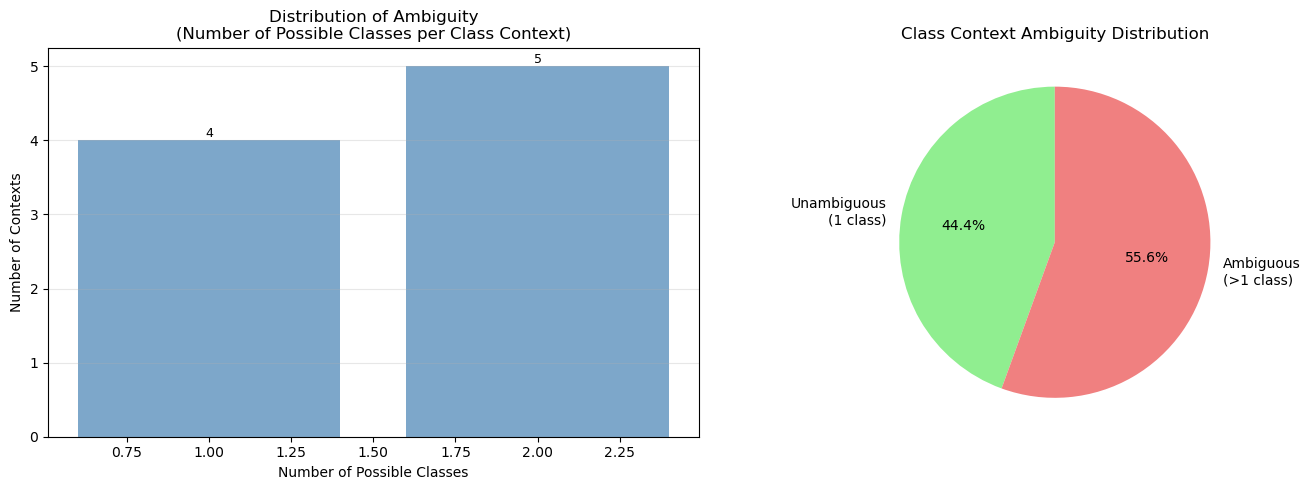


Plot saved to: grammar_ambiguity_analysis.png


In [15]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of number of classes per context
ax = axes[0]
class_counts = sorted(class_count_dist.keys())
counts = [class_count_dist[c] for c in class_counts]
ax.bar(class_counts, counts, alpha=0.7, color='steelblue')
ax.set_xlabel('Number of Possible Classes')
ax.set_ylabel('Number of Contexts')
ax.set_title('Distribution of Ambiguity\n(Number of Possible Classes per Class Context)')
ax.grid(True, alpha=0.3, axis='y')
for i, (c, cnt) in enumerate(zip(class_counts, counts)):
    ax.text(c, cnt, f'{cnt:,}', ha='center', va='bottom', fontsize=9)

# Plot 2: Pie chart of ambiguous vs unambiguous
ax = axes[1]
sizes = [len(unambiguous_contexts), len(ambiguous_contexts)]
labels = ['Unambiguous\n(1 class)', 'Ambiguous\n(>1 class)']
colors = ['lightgreen', 'lightcoral']
ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Class Context Ambiguity Distribution')

plt.tight_layout()
plt.savefig('grammar_ambiguity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to: grammar_ambiguity_analysis.png")


In [16]:
# Method 3: Analyze grammar rules directly to understand why ambiguity exists
print(f"\n{'='*60}")
print("METHOD 3: GRAMMAR RULE ANALYSIS")
print(f"{'='*60}")

# Check which non-terminals can produce which terminal categories
# This helps understand the source of ambiguity

def get_terminal_categories_at_end(grammar, non_terminal, max_depth=10, visited=None):
    """Recursively find all terminal categories that can appear at the END of a non-terminal"""
    if visited is None:
        visited = set()
    
    if non_terminal in visited or max_depth <= 0:
        return set()
    
    visited.add(non_terminal)
    categories = set()
    
    # Get all productions for this non-terminal
    productions = [p for p in grammar.productions() if str(p.lhs()) == non_terminal]
    
    for prod in productions:
        rhs = prod.rhs()
        if len(rhs) == 1:
            # Terminal production - this is the end
            if isinstance(rhs[0], str):
                # Extract category from word like "word(N)"
                if '(' in rhs[0] and ')' in rhs[0]:
                    cat = rhs[0].split('(')[1].rstrip(')')
                    categories.add(cat)
                else:
                    # Direct terminal, category is the LHS
                    categories.add(non_terminal)
        else:
            # Non-terminal production - check what can end the LAST symbol in RHS
            last_symbol = rhs[-1]
            if isinstance(last_symbol, str):
                # Last symbol is terminal
                if '(' in last_symbol and ')' in last_symbol:
                    cat = last_symbol.split('(')[1].rstrip(')')
                    categories.add(cat)
                else:
                    categories.add(non_terminal)
            else:
                # Last symbol is non-terminal - recurse
                symbol_str = str(last_symbol)
                sub_categories = get_terminal_categories_at_end(grammar, symbol_str, max_depth-1, visited.copy())
                categories.update(sub_categories)
    
    return categories

# Check what categories can end different structures
print(f"\nTerminal categories that can appear at the END:")
for nt in ['S', 'NP', 'VP', 'PP']:
    categories = get_terminal_categories_at_end(grammar, nt)
    print(f"  {nt} can end with: {sorted(categories)}")

# Since S -> NP VP, the last word comes from VP
# Check what VP can end with
vp_categories = get_terminal_categories_at_end(grammar, 'VP')
print(f"\nVP (which produces the last word in S -> NP VP) can end with: {sorted(vp_categories)}")
print(f"\nThis shows the grammar allows multiple classes at the sentence end position.")

# Summary
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")
print(f"1. Grammar allows multiple classes for the last word position")
print(f"2. {len(ambiguous_contexts):,} out of {len(context_to_classes):,} class contexts ({100*len(ambiguous_contexts)/len(context_to_classes):.2f}%) are ambiguous")
print(f"3. {ambiguous_sentence_count:,} out of {total_sentences:,} sentences ({100*ambiguous_sentence_count/total_sentences:.2f}%) have ambiguous class contexts")
print(f"4. This explains why the model may struggle - there is genuine class-level ambiguity in the grammar")
print(f"5. Analysis uses class sequences (not words) since grammar nondeterminism is about class patterns")



METHOD 3: GRAMMAR RULE ANALYSIS

Terminal categories that can appear at the END:
  S can end with: ['N', 'NP']
  NP can end with: ['N', 'NP']
  VP can end with: ['N', 'NP']
  PP can end with: ['N', 'NP']

VP (which produces the last word in S -> NP VP) can end with: ['N', 'NP']

This shows the grammar allows multiple classes at the sentence end position.

SUMMARY
1. Grammar allows multiple classes for the last word position
2. 5 out of 9 class contexts (55.56%) are ambiguous
3. 157,361 out of 200,000 sentences (78.68%) have ambiguous class contexts
4. This explains why the model may struggle - there is genuine class-level ambiguity in the grammar
5. Analysis uses class sequences (not words) since grammar nondeterminism is about class patterns


In [17]:
# Detailed ambiguity analysis: How ambiguous are the ambiguous contexts?
print(f"\n{'='*60}")
print("AMBIGUITY LEVEL ANALYSIS FOR AMBIGUOUS CONTEXTS")
print(f"{'='*60}")

# For each ambiguous context, count how many times each class appears
context_class_counts = defaultdict(lambda: defaultdict(int))  # context -> class -> count

for sentences, classes_list in [(uniform_sentences, uniform_classes), (zipfian_sentences, zipfian_classes)]:
    for sent, classes in zip(sentences, classes_list):
        if len(classes) >= n_context:
            context_classes = classes[:n_context-1]
            context_str = ' '.join(context_classes)
            last_class = classes[n_context-1]
            
            if context_str in ambiguous_contexts:
                context_class_counts[context_str][last_class] += 1

print(f"\nDetailed breakdown of ambiguous contexts:")
print(f"{'Context':<25} {'Class':<10} {'Count':<10} {'Percentage':<12} {'Total'}")
print("-" * 80)

for ctx in sorted(ambiguous_contexts.keys()):
    total = context_counts[ctx]
    class_dist = context_class_counts[ctx]
    
    print(f"\n{ctx:<25}")
    for cls in sorted(class_dist.keys()):
        count = class_dist[cls]
        pct = 100 * count / total
        print(f"{'':<25} {cls:<10} {count:<10} {pct:>6.2f}%     {total}")
    
    # Calculate entropy (measure of ambiguity)
    entropy = -sum((count/total) * np.log2(count/total) for count in class_dist.values())
    max_entropy = np.log2(len(class_dist))  # Maximum entropy for this many classes
    normalized_entropy = entropy / max_entropy if max_entropy > 0 else 0
    print(f"{'':<25} {'Entropy':<10} {entropy:.3f}     (normalized: {normalized_entropy:.3f})")

# Calculate optimal accuracy
print(f"\n{'='*60}")
print("OPTIMAL ACCURACY CALCULATION")
print(f"{'='*60}")

# For unambiguous contexts: 100% accuracy
unambiguous_total = sum(context_counts[ctx] for ctx in unambiguous_contexts.keys())
unambiguous_correct = unambiguous_total  # Always correct

# For ambiguous contexts: pick the most frequent class
ambiguous_correct = 0
ambiguous_total = 0

for ctx in ambiguous_contexts.keys():
    class_dist = context_class_counts[ctx]
    total = context_counts[ctx]
    most_frequent_count = max(class_dist.values())
    
    ambiguous_correct += most_frequent_count
    ambiguous_total += total

total_correct = unambiguous_correct + ambiguous_correct
total_instances = unambiguous_total + ambiguous_total

optimal_accuracy = 100 * total_correct / total_instances

print(f"\nUnambiguous contexts:")
print(f"  Instances: {unambiguous_total:,}")
print(f"  Correct (always): {unambiguous_correct:,}")
print(f"  Accuracy: 100.00%")

print(f"\nAmbiguous contexts:")
print(f"  Instances: {ambiguous_total:,}")
print(f"  Correct (picking most frequent class): {ambiguous_correct:,}")
print(f"  Accuracy: {100 * ambiguous_correct / ambiguous_total:.2f}%")

print(f"\n{'='*60}")
print(f"OPTIMAL ACCURACY (if model always picks most frequent class): {optimal_accuracy:.2f}%")
print(f"{'='*60}")

# Breakdown by context
print(f"\nOptimal accuracy breakdown by ambiguous context:")
print(f"{'Context':<25} {'Total':<10} {'Most Freq':<12} {'Accuracy':<10}")
print("-" * 60)
for ctx in sorted(ambiguous_contexts.keys()):
    class_dist = context_class_counts[ctx]
    total = context_counts[ctx]
    most_frequent_count = max(class_dist.values())
    ctx_accuracy = 100 * most_frequent_count / total
    most_freq_class = max(class_dist.items(), key=lambda x: x[1])[0]
    print(f"{ctx:<25} {total:<10} {most_freq_class} ({most_frequent_count:<6}) {ctx_accuracy:>6.2f}%")



AMBIGUITY LEVEL ANALYSIS FOR AMBIGUOUS CONTEXTS

Detailed breakdown of ambiguous contexts:
Context                   Class      Count      Percentage   Total
--------------------------------------------------------------------------------

Det Adj N P              
                          Det        33988       80.05%     42459
                          OTHER      8471        19.95%     42459
                          Entropy    0.721     (normalized: 0.721)

Det Adj N V              
                          Det        34090       79.97%     42629
                          OTHER      8539        20.03%     42629
                          Entropy    0.723     (normalized: 0.723)

Det N P Det              
                          Adj        16981       49.66%     34195
                          N          17214       50.34%     34195
                          Entropy    1.000     (normalized: 1.000)

Det N V Det              
                          Adj        16772       49.61%

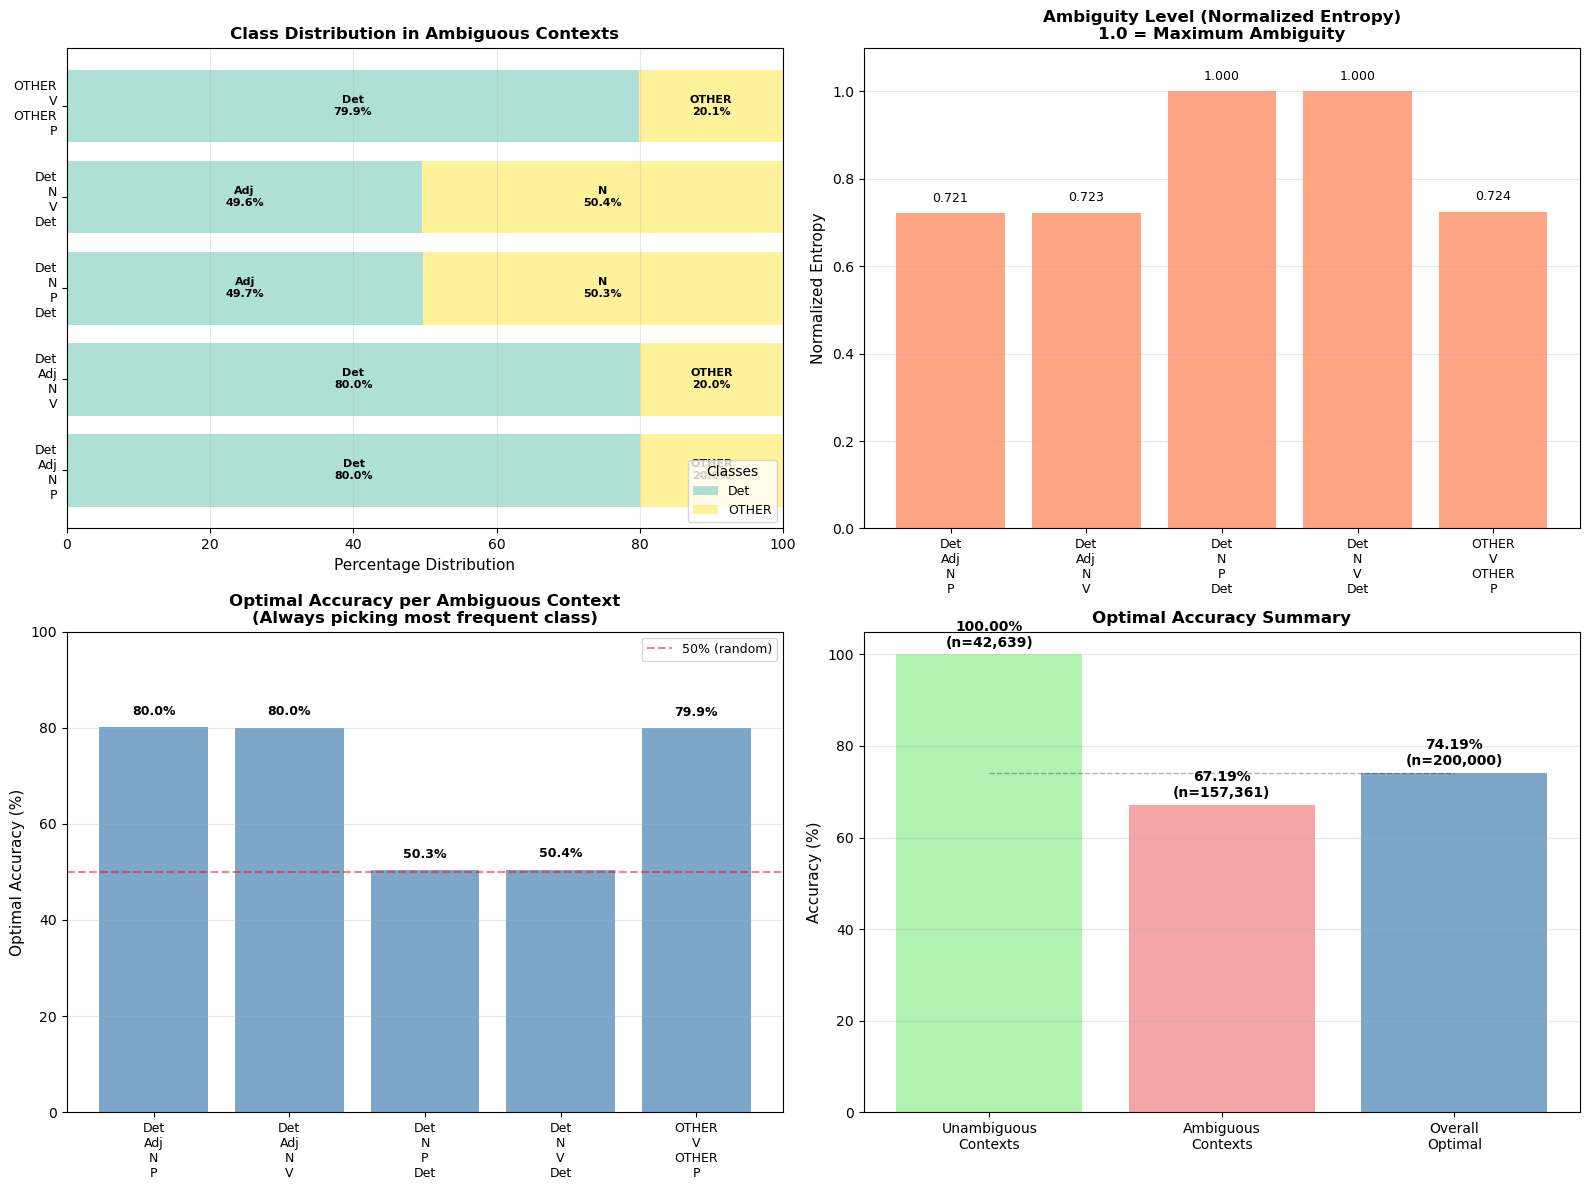


Detailed visualization saved to: grammar_ambiguity_detailed_analysis.png


In [18]:
# Visualization of ambiguity levels and optimal accuracy
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Class distribution for each ambiguous context
ax = axes[0, 0]
contexts = sorted(ambiguous_contexts.keys())
y_pos = np.arange(len(contexts))
width = 0.35

# Get class distributions
for i, ctx in enumerate(contexts):
    class_dist = context_class_counts[ctx]
    total = context_counts[ctx]
    classes = sorted(class_dist.keys())
    
    # Create stacked bar or grouped bars
    bottom = 0
    colors = plt.cm.Set3(np.linspace(0, 1, len(classes)))
    for j, cls in enumerate(classes):
        count = class_dist[cls]
        pct = 100 * count / total
        ax.barh(i, pct, left=bottom, label=cls if i == 0 else "", color=colors[j], alpha=0.7)
        if pct > 5:  # Only label if significant
            ax.text(bottom + pct/2, i, f'{cls}\n{pct:.1f}%', 
                   ha='center', va='center', fontsize=8, fontweight='bold')
        bottom += pct

ax.set_yticks(y_pos)
ax.set_yticklabels([ctx.replace(' ', '\n') for ctx in contexts], fontsize=9)
ax.set_xlabel('Percentage Distribution', fontsize=11)
ax.set_title('Class Distribution in Ambiguous Contexts', fontsize=12, fontweight='bold')
ax.set_xlim(0, 100)
ax.grid(True, alpha=0.3, axis='x')
ax.legend(title='Classes', loc='lower right', fontsize=9)

# Plot 2: Entropy (ambiguity measure) for each context
ax = axes[0, 1]
entropies = []
max_entropies = []
normalized_entropies = []
context_labels = []

for ctx in contexts:
    class_dist = context_class_counts[ctx]
    total = context_counts[ctx]
    entropy = -sum((count/total) * np.log2(count/total) for count in class_dist.values())
    max_entropy = np.log2(len(class_dist))
    normalized_entropy = entropy / max_entropy if max_entropy > 0 else 0
    
    entropies.append(entropy)
    max_entropies.append(max_entropy)
    normalized_entropies.append(normalized_entropy)
    context_labels.append(ctx.replace(' ', '\n'))

x_pos = np.arange(len(contexts))
ax.bar(x_pos, normalized_entropies, alpha=0.7, color='coral')
ax.set_xticks(x_pos)
ax.set_xticklabels(context_labels, fontsize=9, rotation=0)
ax.set_ylabel('Normalized Entropy', fontsize=11)
ax.set_title('Ambiguity Level (Normalized Entropy)\n1.0 = Maximum Ambiguity', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')
for i, (ent, norm_ent) in enumerate(zip(entropies, normalized_entropies)):
    ax.text(i, norm_ent + 0.02, f'{norm_ent:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 3: Optimal accuracy breakdown
ax = axes[1, 0]
context_accuracies = []
for ctx in contexts:
    class_dist = context_class_counts[ctx]
    total = context_counts[ctx]
    most_frequent_count = max(class_dist.values())
    ctx_accuracy = 100 * most_frequent_count / total
    context_accuracies.append(ctx_accuracy)

x_pos = np.arange(len(contexts))
bars = ax.bar(x_pos, context_accuracies, alpha=0.7, color='steelblue')
ax.set_xticks(x_pos)
ax.set_xticklabels(context_labels, fontsize=9, rotation=0)
ax.set_ylabel('Optimal Accuracy (%)', fontsize=11)
ax.set_title('Optimal Accuracy per Ambiguous Context\n(Always picking most frequent class)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)
ax.axhline(y=50, color='r', linestyle='--', alpha=0.5, label='50% (random)')
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=9)
for i, acc in enumerate(context_accuracies):
    ax.text(i, acc + 2, f'{acc:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 4: Overall optimal accuracy summary
ax = axes[1, 1]
categories = ['Unambiguous\nContexts', 'Ambiguous\nContexts', 'Overall\nOptimal']
accuracies = [100.0, 100 * ambiguous_correct / ambiguous_total, optimal_accuracy]
counts = [unambiguous_total, ambiguous_total, total_instances]
colors = ['lightgreen', 'lightcoral', 'steelblue']

bars = ax.bar(categories, accuracies, alpha=0.7, color=colors)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Optimal Accuracy Summary', fontsize=12, fontweight='bold')
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (acc, count) in enumerate(zip(accuracies, counts)):
    ax.text(i, acc + 1, f'{acc:.2f}%\n(n={count:,})', 
           ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Add a line showing the breakdown
    if i == 2:  # Overall
        ax.plot([0, 2], [acc, acc], 'k--', alpha=0.3, linewidth=1)

plt.tight_layout()
plt.savefig('grammar_ambiguity_detailed_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDetailed visualization saved to: grammar_ambiguity_detailed_analysis.png")
